In [89]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import scipy as sp
from statsmodels.graphics.gofplots import qqplot


## Задача 1. 
Генерирайте 1000 наблюдения над нормално разпределена случайна величина със средно 5 и вариация 12. Начертаите Q-Q plot на наблюденията спрямо разпределението, от което са избрани.

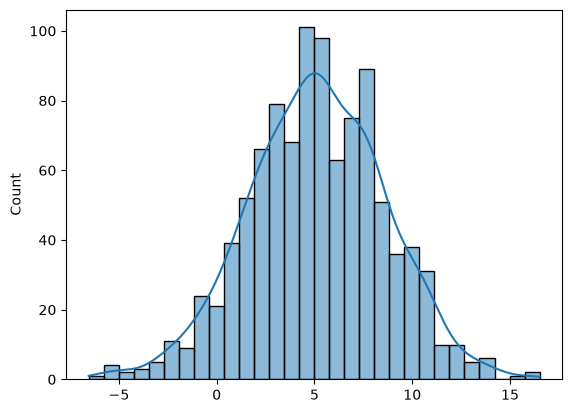

In [90]:
rng = np.random.default_rng(seed=3) # За да възпроизведем резултатите, използваме фиксиран seed

mu = 5
var = 12
sigma = np.sqrt(var)

norm_sample = rng.normal(mu, sigma, 1000)

sb.histplot(norm_sample, bins=30, kde=True)
plt.show()

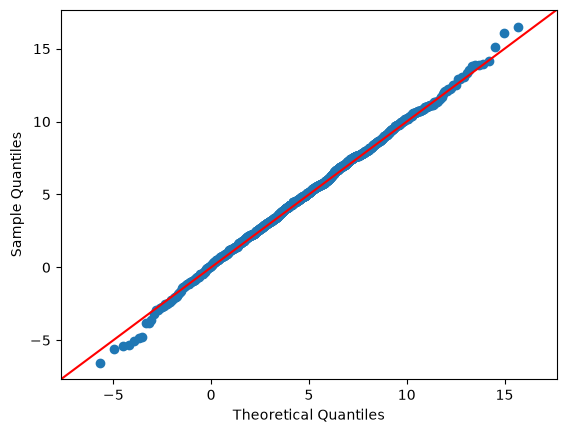

In [91]:
plot = qqplot(norm_sample, line='45', loc=mu, scale=sigma)

## Задача 2. 
Имплементирайте фунцкия, която начертава Q-Q plot спрямо нормалното разпределение от подадени едномерни данни

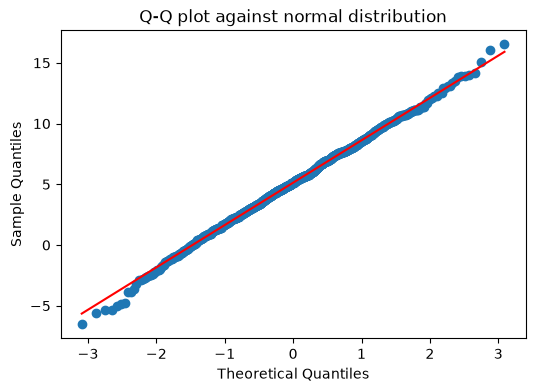

In [99]:
def custom_qqplot_normal(sample):
    n = len(sample)

    ordered = np.sort(sample)
    index = np.arange(1, n + 1)

    probabilities = index / (n + 1)
    th_quantiles = sp.stats.norm.ppf(probabilities)

    x_line = np.array([th_quantiles.min(), th_quantiles.max()])
    y_line = sample.mean() + x_line*sample.std()

    plt.figure(figsize=(6, 4))
    plt.scatter(th_quantiles, ordered)
    plt.plot(x_line, y_line, color="red")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.title("Q-Q plot against normal distribution")
    plt.show()

custom_qqplot_normal(norm_sample)

## Задача 3. 
Имплементирайте фунцкия, която начертава Q-Q plot на едномерни данни спрямо дадено вероятностно резпределение като втори параметър.

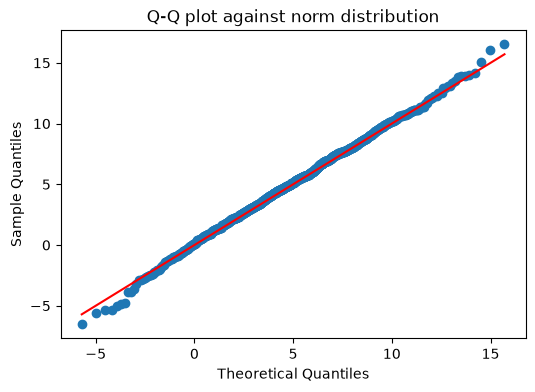

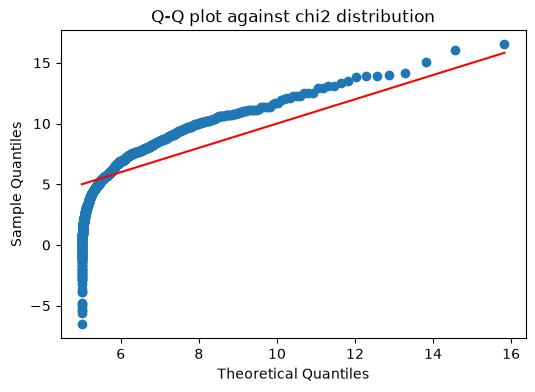

In [ ]:
def custom_qqplot(sample, distribution, *args, **kwargs):
    n = len(sample)

    ordered = np.sort(sample)
    index = np.arange(1, n + 1)

    probabilities = index / (n + 1)
    th_quantiles = distribution.ppf(probabilities, *args, **kwargs)

    x_line = np.array([th_quantiles.min(), th_quantiles.max()])
    y_line = x_line

    plt.subplots(figsize=(6, 4))
    plt.scatter(th_quantiles, ordered)
    plt.plot(x_line, y_line, color="red")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.title(f"Q-Q plot against {distribution.name} distribution")
    plt.show()

custom_qqplot(norm_sample, sp.stats.norm, loc=mu, scale=sigma)
custom_qqplot(norm_sample, sp.stats.chi2, loc=mu, df=1)

## Задача 4.
Генерирайте 100 наблюдения от триъгълно разпределение с параметри (2, 5, 10). Начертайте Q-Q plot на данните спрямо теоретичните квантили, използвайки функцията от зад. 2

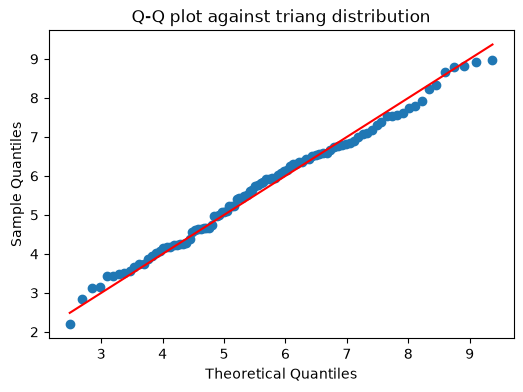

In [ ]:
rng = np.random.default_rng(seed=3) # За да възпроизведем резултатите, използваме фиксиран seed

triang_sample = rng.triangular(2, 5, 10, 100)

# Параметрите на триъгълнoто разпределение са: low, mode и high. В нашия случай low=2, mode=5 и high=10.
#
# В документацията на `scipy.stats.triang` пише: 
# 
# "The triangular distribution can be represented with an up-sloping line from loc to (loc + c*scale) 
#  and then downsloping for (loc + c*scale) to (loc + scale)."
# 
# Значи имаме:
# 
# loc = 2 (стартова точка на дистрибуцията)
# 
# high = loc + scale (крайна точка на дистрибуцията) 
#   => scale = 10 - 2
# 
# mode = loc + c*scale (среда на дистрибуцията) 
#   => 5 = 2 + c*(10 - 2) 
#   => c = (5 - 2) / (10 - 2)
custom_qqplot(triang_sample, sp.stats.triang, c=(5 - 2) / (10 - 2), loc=2, scale=10 - 2)


## * Задача 5.
Генерирайте 100 наблюдения от t-разпределението със степен на свобода 5. Начертайте Q-Q plot на данните спрямо теоретичните квантили, използвайки функцията от зад. 2

## Задача 6. 
Генерирайте 100 наблюдения над случайната величина $X\sim \mathcal{N}_5(\mu, \Sigma)$, където $\mu$ и $\Sigma$ произволни. Тествайте за нормалност чрез Q-Q plot.

Ако данните следват нормално разпределение, квадратите на генерализираните разстояния от средното $d^2_i = (x_i - \bar x)^T S^2 (x_i - \bar x)$ следват $\chi^2_p$ разпределение. Следователно, ако пресметнем тези разстояния, можем да тестваме данните за нормалност като тестваме разстоянията за $\chi^2_p$ разпределение.

## Задача 7.
Тествайте данните във файла 'data/lumber_stiffness.csv':
1. За нормалнмост чрез Q-Q плот
2. За екстремални стойности (outliers) като пресметнете квадратите на генерализираните разстояния (които са разпределени като $\chi^2_p$) и ги сравните с критичната стойност $\chi^2_{p, 0.02}$

## ** Задача 7.
Начертайте scatterpolts между промеливите от данните в предишната задача (общо 12 плота). Оцветете екстремалните стойности в различен цвят. (фиг. 4.11 от учебника Applied Multivariate Statistical Analysis, Johnson & Wichern)